In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Importazione dei file
Importo da google drive i file CSV contenenti i dati delle run, analizzando una configurazione (al variare del parametro m) alla volta.

Per calcolare i risultati relativi a una configurazione, è sufficiente decommentare la riga gdown.download(...) corrispondente alla configurazione di m desiderata.

In [2]:
import gdown

# ID dei file
file_m_10 = "1R73KH9l8T6CpBcnqYLGeOm7baD1XLqB8"
file_m_14 = "1T0ryvHj_JSj9Hb5g41ujNXifNH_vizlR"
file_m_20 = "1GTjtNzcsTAsNcmQi08HVMLZAwPoPInTQ"
file_m_25 = "1sZvkyPXDEMKGSothhKOTneUegkd_3RzG"

#gdown.download(f"https://drive.google.com/uc?id={file_m_10}", "data.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file_m_14}", "data.csv", quiet=False)
#gdown.download(f"https://drive.google.com/uc?id={file_m_20}", "data.csv", quiet=False)
#gdown.download(f"https://drive.google.com/uc?id={file_m_25}", "data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1T0ryvHj_JSj9Hb5g41ujNXifNH_vizlR
To: /content/data.csv
100%|██████████| 64.7M/64.7M [00:00<00:00, 72.4MB/s]


'data.csv'

# Preprocessing del file
A partire dal file CSV, preparo un dizionario che raggruppa per ciascuna metrica le coppie (tempo, valore) per ogni run.

In [3]:
df = pd.read_csv("data.csv") # importa il file data.csv in un DataFrame pandas

# colonne di interesse
metric_map = {"NumUsersSystemClass1": 0, "NumUsersSystemClass2": 1, "VacationDurations": 2, "utilization": 3, "TimeInSystemClass1": 4, "TimeInSystemClass2": 5}
metrics = ["NumUsersSystemClass1", "NumUsersSystemClass2", "VacationDurations", "utilization", "TimeInSystemClass1", "TimeInSystemClass2"]

# parametri di simulazione
run = 20
total_simulation_time = 15000

# creazione di un dizionario che raggruppa le coppie (tempo, valore) per ogni run e metrica
data = {}

# costruisci il dizionario
for metric in metrics:
    time_cols = [c for c in df.columns if c.startswith(metric)]
    value_cols  = [df.columns[df.columns.get_loc(c) + 1] for c in time_cols]

    data[metric] = [(df[t].dropna().to_numpy(), df[v].dropna().to_numpy())
                    for t, v in zip(time_cols, value_cols)]


warmup_time = [[], [], [], [], [], []] #lista vuota per memorizzare i tempi di warmup di ogni metrica

# Individuazione del transiente iniziale

A seguire, viene implementato un metodo per stimare la fine della fase transiente di una simulazione. In questa fase, le metriche della simulazione non sono ancora stabili e i valori osservati non rappresentano il comportamento a regime del sistema. Identificare la fine di questa fase è fondamentale per analizzare correttamente le metriche della simulazione senza introdurre bias dovuti ai valori iniziali.

Approccio adottato (ripetuto per ogni metrica):
1. **Media tra repliche indipendenti**: per ogni istante n si calcola la media dei valori tra le repliche. Si effettua un'**interpolazione** sui timestamp per mettere tutte le repliche sulla stessa griglia temporale, dato che ogni run della simulazione può avere tempi di osservazione leggermente diversi.
2. **Welch smoothing**: per attenuare le fluttuazioni a breve termine, la sequenza viene smussata utilizzando una media mobile centrata di finestra 2K+1. Per i punti iniziali, dove la finestra non può essere centrata, si adatta la media mobile a una finestra più corta. Questo passaggio produce una curva più regolare che facilita l’individuazione del transiente.
3. **Rilevamento automatico del warm-up**: la fine del transiente viene stimata confrontando la curva smussata con il valore asintotico stimato. In particolare:
  *   si stima il valore medio a regime come la media dell’ultimo 20% della curva smussata (mu_final);
  *  si definisce una banda di tolleranza ammessa attorno a mu_final;
  *   il tempo di fine transiente (warm-up) è il primo istante a partire dal quale la curva smussata rimane stabile all’interno di questa banda per un numero consecutivo di punti definito dalla finestra window.  



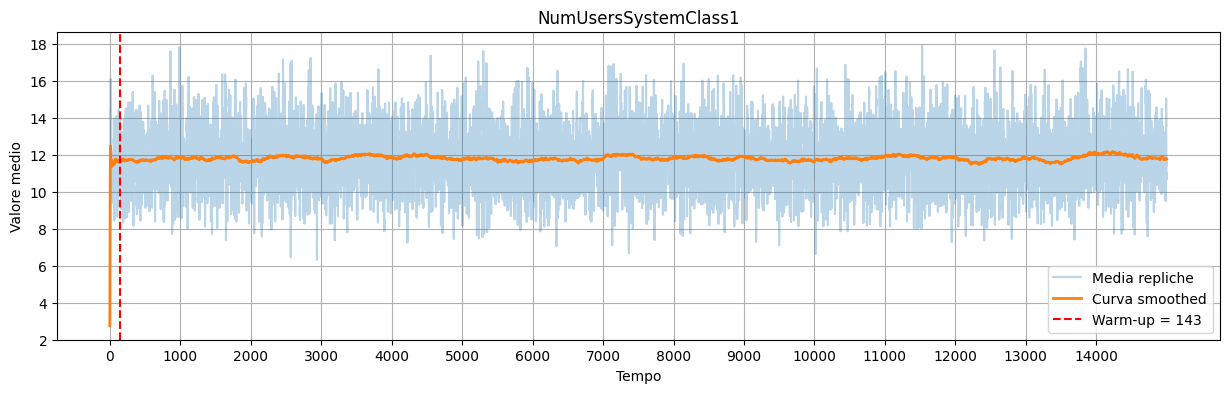

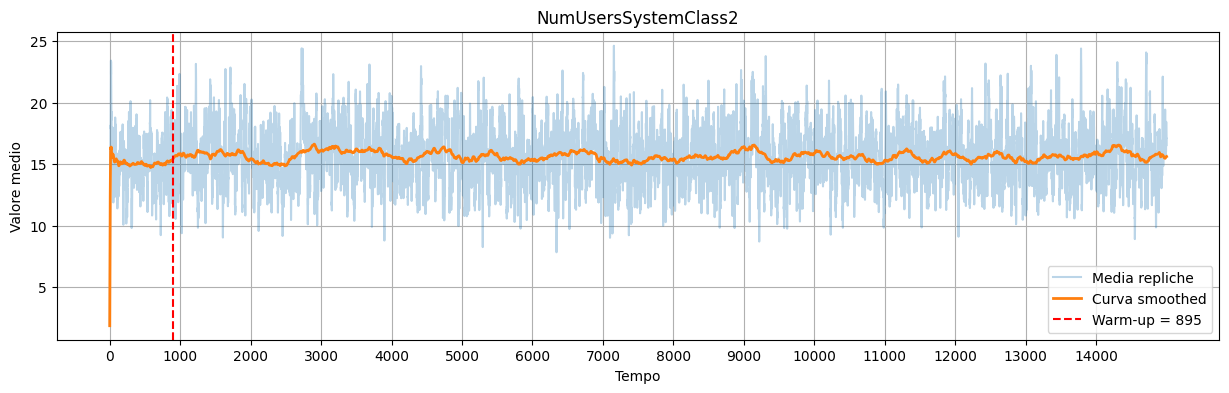

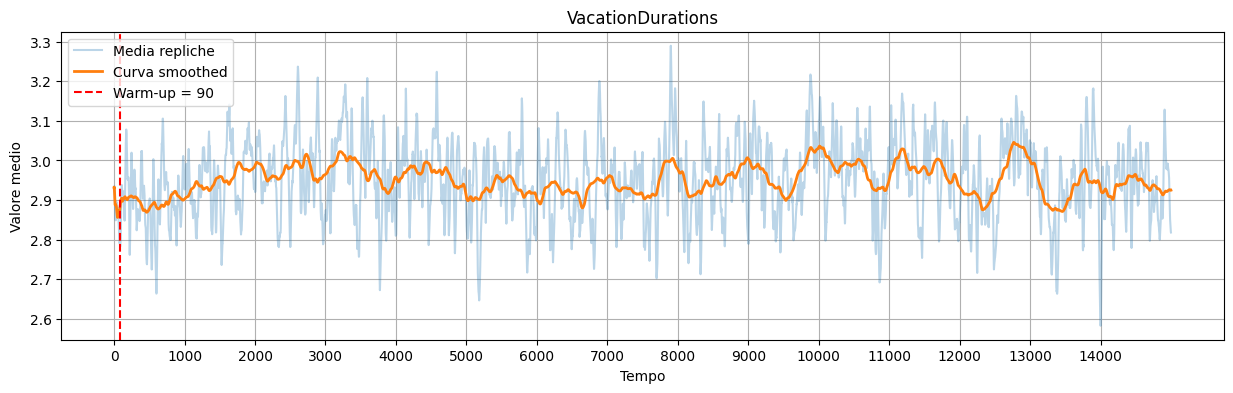

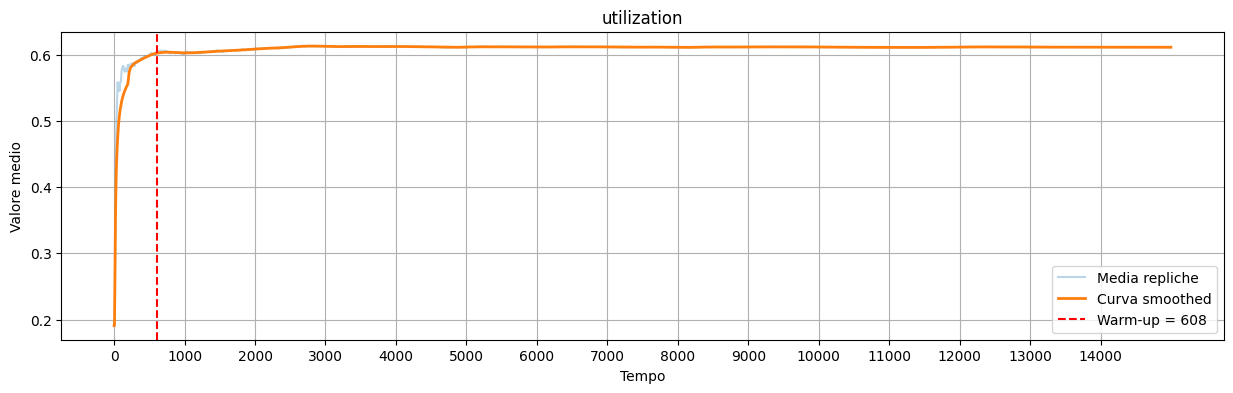

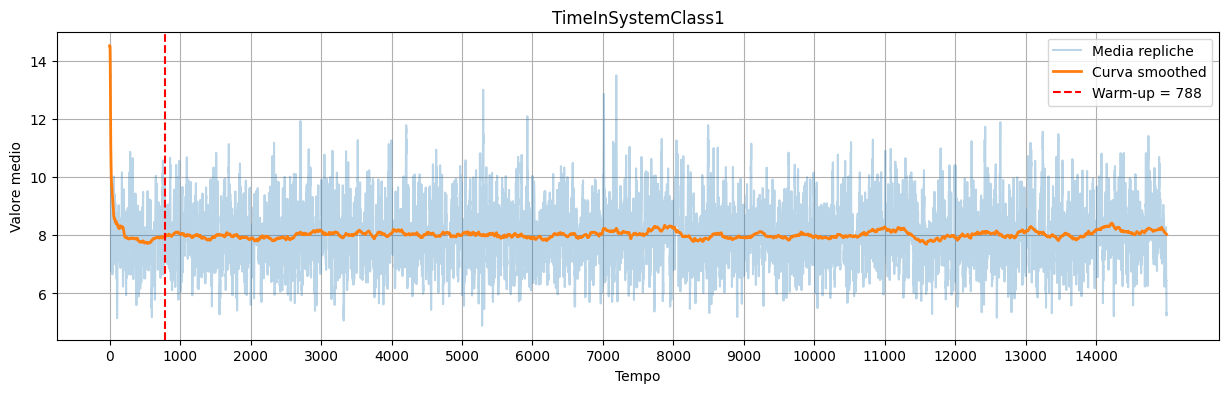

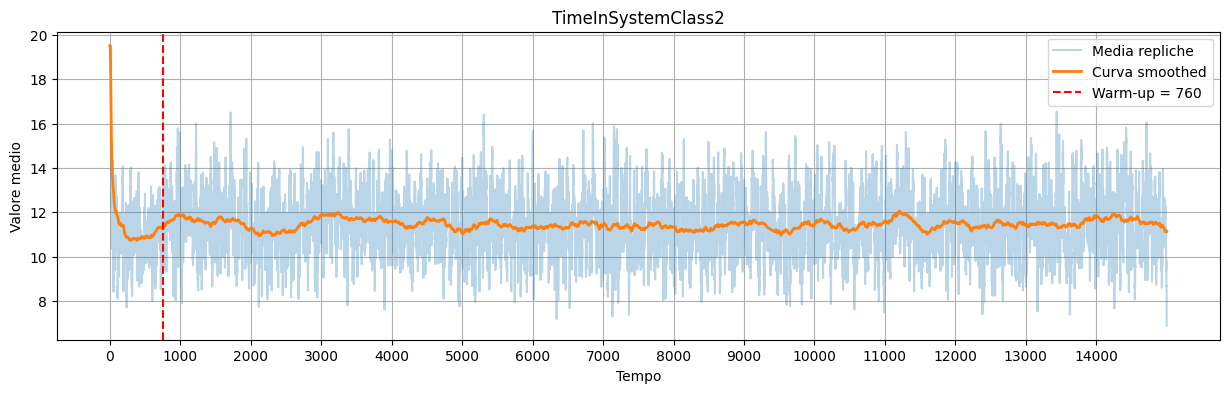

In [4]:
# ---------------------------------------
# 1) Media tra repliche con interpolazione
# ---------------------------------------
def replication_mean(data, metric, total_simulation_time):
    runs_data = data[metric]
    time_grid = np.arange(total_simulation_time)

    interpolated_values = []

    for t, v in runs_data:
      t = np.array(t)
      v = np.array(v)

      if metric == "utilization":
          busy_cumsum = np.cumsum(v)
          utilization = busy_cumsum / t  # fattore di utilizzo = busy cumulato / tempo trascorso
          utilization[t == 0] = 0
          interp_v = np.interp(time_grid, t, utilization)
      else:
          interp_v = np.interp(time_grid, t, v) # interpolazione lineare

      interpolated_values.append(interp_v)

    interpolated_values = np.array(interpolated_values)
    hat_mu = np.mean(interpolated_values, axis=0)

    return time_grid, hat_mu

# ---------------------------
# 2) Welch smoothing
# ---------------------------
def welch_smoothing(hat_mu, K):
    N = len(hat_mu)
    smoothed = np.zeros(N)

    for n in range(N):
        if n >= K:
            start = n - K
            end = min(n + K + 1, N)
        else:
            start = 0
            end = min(2*n + 1, N)

        smoothed[n] = np.mean(hat_mu[start:end])

    return smoothed

# ---------------------------------------
# 3) Rilevamento warm-up
# ---------------------------------------
def detect_warmup(smoothed_curve, tolerance, window):
    N = len(smoothed_curve)

    # stima media finale = ultimo 20%
    tail = smoothed_curve[int(0.8*N):]
    mu_final = np.mean(tail)

    band = tolerance * abs(mu_final)

    lower = mu_final - band
    upper = mu_final + band

    for i in range(N - window):
        if np.all((smoothed_curve[i:i+window] >= lower) &
                  (smoothed_curve[i:i+window] <= upper)):
            return i

    return 0

# ---------------------------------------
# 4) Applicazione a tutte le metriche
# ---------------------------------------
warmup_time = []

K = round(1.6 * int(np.sqrt(total_simulation_time)))  # dimensione della semi-finestra

for metric in metrics:
    time_grid, hat_mu = replication_mean(data, metric, total_simulation_time)
    smoothed = welch_smoothing(hat_mu, K)
    warmup = detect_warmup(smoothed, tolerance=0.015, window=100)
    warmup_time.append(warmup)

    # Plot
    plt.figure(figsize=(15,4))
    #plt.xlim(0, 3000)
    plt.plot(time_grid, hat_mu, alpha=0.3, label="Media repliche")
    plt.plot(time_grid, smoothed, linewidth=2, label="Curva smoothed")
    plt.axvline(warmup, color='red', linestyle='--', label=f"Warm-up = {warmup}")
    plt.title(f"{metric}")
    plt.xlabel("Tempo")
    plt.ylabel("Valore medio")
    plt.xticks(np.arange(0, len(time_grid), 1000))
    plt.legend()
    plt.grid(True)
    plt.show()

# Definizione del tempo di warm-up
Approccio:
1. Si calcola il tempo di fine transiente per ogni metrica.
2. Si prende il massimo tra tutte le metriche per garantire il regime stazionario generale.
3. Si aggiunge un margine di sicurezza del 20% per essere certi di non includere dati transitori nelle analisi statistiche.

In [ ]:
print("\nWarm-up stimati per ogni metrica:\n")
for m, w in zip(metrics, warmup_time):
    print(f"{m:25} {w:>10}")

# tempo di fine transiente più lungo tra tutte le metriche
warmup_final = max(warmup_time)
print(f"\nWarm up calcolato: {warmup_final:>10}")

# Per sicurezza, taglio qualche secondo in più dopo la fine stimata del transiente
warmup_final_margin = round(warmup_final * 1.2)
print(f"\nWarm up con 20% di margine in più: {warmup_final_margin:>10}")


Warm-up stimati per ogni metrica:

NumUsersSystemClass1             143
NumUsersSystemClass2             895
VacationDurations                 90
utilization                      608
TimeInSystemClass1               788
TimeInSystemClass2               760

Warm up calcolato:        895

Warm up con 20% di margine in più:       1074


# Calcolo delle stime puntuali e della deviazione standard
Per ciascuna metrica, vengono calcolate:
* La stima puntuale (media tra run, metodo metodo delle repliche indipendenti).
* La deviazione standard tra run.

Viene innanzitutto applicata una maschera per eliminare la fase transiente, considerando solo i dati successivi a warmup_final_margin. In questo modo, le stime considerano solo il regime stazionario della simulazione.

Vengono calcolate stime diverse a seconda del tipo di metrica:
* media temporale (NumUsers)
* media campionaria (TimeInSystem, VacationDurations)
* rapporto di tempo (utilization)

In [ ]:
#Calcolo stima puntuale
meanMetrics = {}

for m in metrics:
  meanMetrics[m] = []

  for i in range(run):
    t_data, v_data = data[m][i]

    #rimozione dei dati relativi alla fase transiente
    mask = t_data >= warmup_final_margin
    v_data = v_data[mask]
    t_data = t_data[mask]

    if m == "utilization":
      busy_time = np.sum(v_data)
      meanMetrics[m].append(busy_time / (total_simulation_time - warmup_final_margin)) #fattore di utilizzo del sistema
    elif m in ["NumUsersSystemClass1", "NumUsersSystemClass2"]:
      dt = np.diff(t_data)
      weighted_sum = np.sum(v_data[:-1] * dt)
      meanMetrics[m].append(weighted_sum / (t_data[-1] - t_data[0])) #media temporale (time-average)
    else:
      meanMetrics[m].append(np.mean(v_data)) #media campionaria

#print(meanMetrics)

estimate = {}
for m in metrics:
    estimate[m] = np.mean(meanMetrics[m])

print("Stime puntuali:\n")
for k, v in estimate.items():
    print(f"{k:25s}  {v:.4f}")

#Calcolo varianza e deviazione standard (tra run)
variance = {m: np.var(meanMetrics[m], ddof=1) for m in metrics} #ddof=1 serve per definire la varianza campionaria (stimatore non distorto)
std = {m: np.sqrt(variance[m]) for m in metrics}

print("\nDeviazione standard:\n")
for k, v in std.items():
    print(f"{k:25s}  {v:.4f}")

Stime puntuali:

NumUsersSystemClass1       11.8868
NumUsersSystemClass2       15.6964
VacationDurations          2.9541
utilization                0.6122
TimeInSystemClass1         6.6510
TimeInSystemClass2         10.9988

Deviazione standard:

NumUsersSystemClass1       0.0988
NumUsersSystemClass2       0.3363
VacationDurations          0.0185
utilization                0.0073
TimeInSystemClass1         0.0649
TimeInSystemClass2         0.2084


# Calcolo degli intervalli di confidenza
A seguire, vengono calcolati gli intervalli di confidenza al 95% (alpha = 0.05) per tutte le metriche.

L'intervallo di confidenza indica che c’è il 95% di probabilità che la media reale del sistema stazionario cada dentro quell’intervallo, assumendo indipendenza tra run.

Viene utilizzata la distribuzione t di Student perché il numero di run è limitato e la deviazione standard è stimata dal campione: la t compensa l’incertezza aggiuntiva dovuta a pochi dati, fornendo intervalli più realistici rispetto alla normale.

In [ ]:
# Calcolo intervalli di confidenza
alpha = 0.05
confidence_intervals = {}

q_value = t.ppf(1 - alpha/2, df=run-1)

for m in metrics:
    half = q_value * std[m] / np.sqrt(run)
    confidence_intervals[m] = [estimate[m] - half, estimate[m] + half]

print("Intervalli di confidenza:\n")
for i in range(len(metrics)):
    low, high = confidence_intervals[metrics[i]]
    print(f"{metrics[i]:25s}  [{low:.4f} , {high:.4f}]")

Intervalli di confidenza:

NumUsersSystemClass1       [11.8406 , 11.9331]
NumUsersSystemClass2       [15.5390 , 15.8538]
VacationDurations          [2.9455 , 2.9628]
utilization                [0.6088 , 0.6156]
TimeInSystemClass1         [6.6207 , 6.6814]
TimeInSystemClass2         [10.9013 , 11.0963]
